In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('ToyotaCorolla - MLR.csv')

In [3]:
df.shape

(1436, 11)

In [4]:
df.head()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [6]:
print(df['Fuel_Type'].unique())

['Diesel' 'Petrol' 'CNG']


In [7]:
fuel_map = {
    'Petrol': 0,
    'Diesel': 1,
    'CNG': 2,
    }
df['Fuel_Type'] = df['Fuel_Type'].map(fuel_map)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   Price      1436 non-null   int64
 1   Age_08_04  1436 non-null   int64
 2   KM         1436 non-null   int64
 3   Fuel_Type  1436 non-null   int64
 4   HP         1436 non-null   int64
 5   Automatic  1436 non-null   int64
 6   cc         1436 non-null   int64
 7   Doors      1436 non-null   int64
 8   Cylinders  1436 non-null   int64
 9   Gears      1436 non-null   int64
 10  Weight     1436 non-null   int64
dtypes: int64(11)
memory usage: 123.5 KB


In [9]:
### missing values
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [10]:
### duplicates
df.duplicated().sum()

np.int64(1)

In [11]:
df=df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

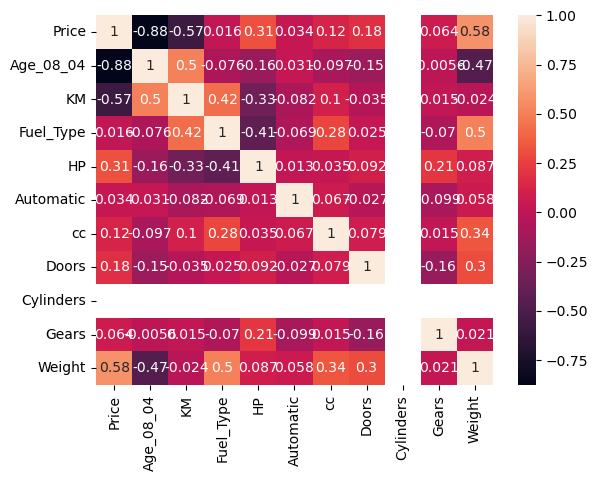

In [13]:
corr=df.corr()
import seaborn as sns
sns.heatmap(corr,annot=True)
plt.show()

In [14]:
df=df.drop('Cylinders',axis=1)
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Gears,Weight
0,13500,23,46986,1,90,0,2000,3,5,1165
1,13750,23,72937,1,90,0,2000,3,5,1165
2,13950,24,41711,1,90,0,2000,3,5,1165
3,14950,26,48000,1,90,0,2000,3,5,1165
4,13750,30,38500,1,90,0,2000,3,5,1170
...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,0,86,0,1300,3,5,1025
1432,10845,72,19000,0,86,0,1300,3,5,1015
1433,8500,71,17016,0,86,0,1300,3,5,1015
1434,7250,70,16916,0,86,0,1300,3,5,1015


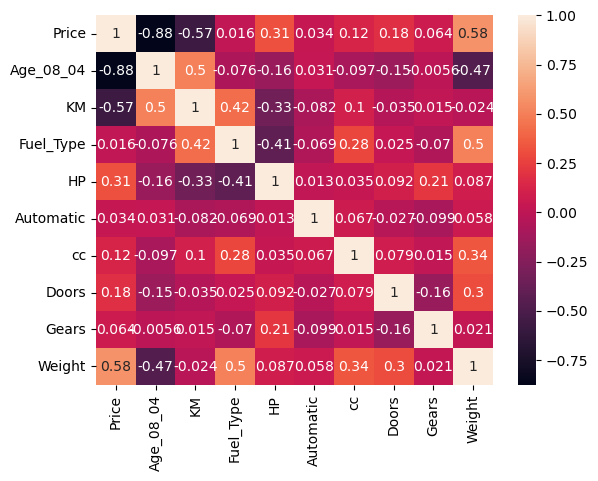

In [15]:
corr=df.corr()
sns.heatmap(corr,annot=True)
plt.show()

array([[<Axes: title={'center': 'Price'}>,
        <Axes: title={'center': 'Age_08_04'}>,
        <Axes: title={'center': 'KM'}>,
        <Axes: title={'center': 'Fuel_Type'}>],
       [<Axes: title={'center': 'HP'}>,
        <Axes: title={'center': 'Automatic'}>,
        <Axes: title={'center': 'cc'}>,
        <Axes: title={'center': 'Doors'}>],
       [<Axes: title={'center': 'Gears'}>,
        <Axes: title={'center': 'Weight'}>, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object)

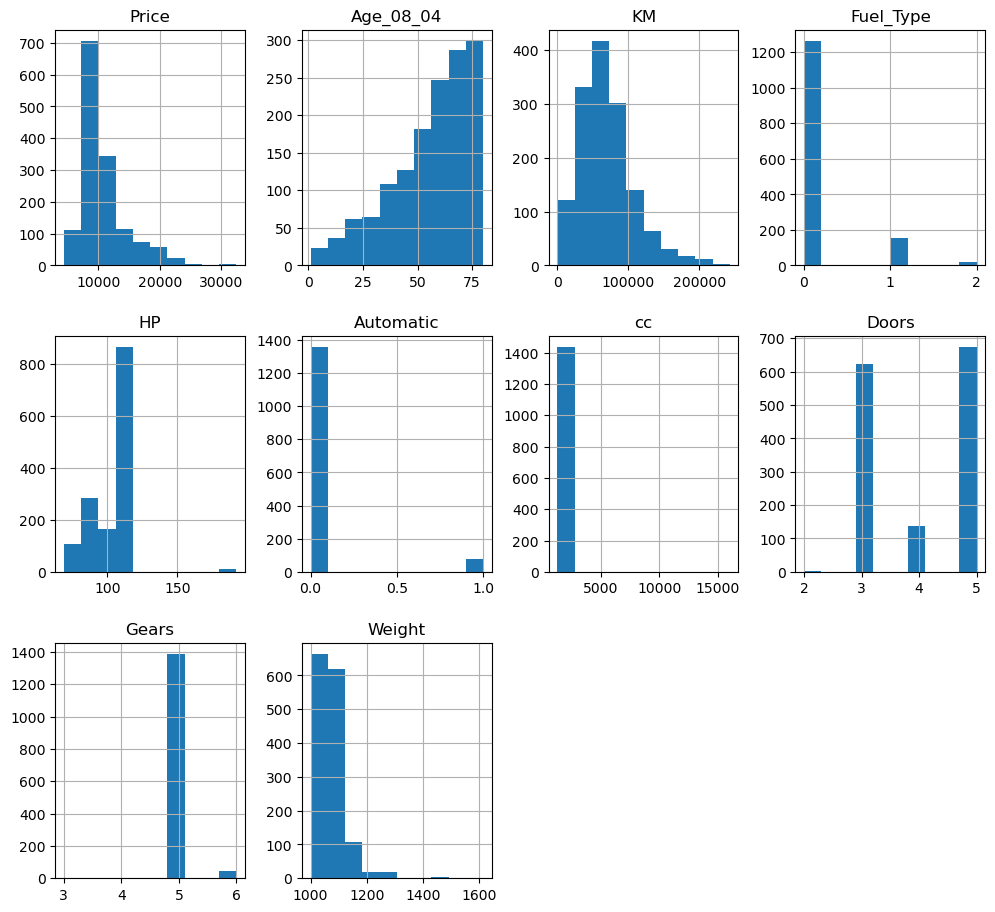

In [16]:
df.hist(figsize=(12,15),layout=(4,4))

In [17]:
x= df.drop(columns=['Price'])
y= df['Price']

In [18]:
x

,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Gears,Weight
0,23,46986,1,90,0,2000,3,5,1165
1,23,72937,1,90,0,2000,3,5,1165
2,24,41711,1,90,0,2000,3,5,1165
3,26,48000,1,90,0,2000,3,5,1165
4,30,38500,1,90,0,2000,3,5,1170
...,...,...,...,...,...,...,...,...,...
1431,69,20544,0,86,0,1300,3,5,1025
1432,72,19000,0,86,0,1300,3,5,1015
1433,71,17016,0,86,0,1300,3,5,1015
1434,70,16916,0,86,0,1300,3,5,1015


In [19]:
y

0       13500
1       13750
2       13950
3       14950
4       13750
        ...  
1431     7500
1432    10845
1433     8500
1434     7250
1435     6950
Name: Price, Length: 1435, dtype: int64

In [20]:
# train test split
from sklearn.model_selection import train_test_split 

In [21]:
x_train,x_test,y_train,y_test= train_test_split(x,y,train_size=0.80,random_state=100)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(1148, 9)
(287, 9)
(1148,)
(287,)


In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
lin_model=LinearRegression()
lin_model.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [24]:
lin_model.coef_

array([-1.24537995e+02, -1.76276977e-02, -3.95421517e+02,  2.62373819e+01,
        3.94335343e+02, -3.00403510e-02,  4.30425267e+00,  7.33844905e+02,
        1.91383362e+01])

In [25]:
lin_model.intercept_

np.float64(-7898.6640968552965)

In [26]:
from sklearn.metrics import r2_score

In [27]:
#### Training validation
y_pred=lin_model.predict(x_train)
r2_score(y_train,y_pred)

0.8626130385692874

In [28]:
#### Testing validation
y_pred1= lin_model.predict(x_test)
r2_score(y_test,y_pred1)

0.8671580177926694

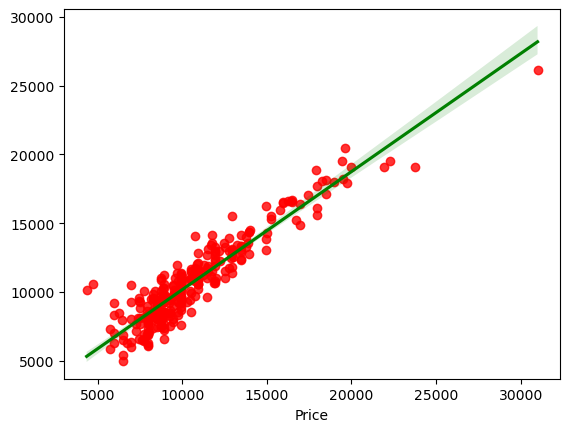

In [29]:
sns.regplot(x=y_test,y=y_pred1,scatter_kws={'color':'red'},line_kws={'color':'green'})
plt.show()

In [30]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,mean_absolute_percentage_error

In [31]:
### mean squared error
mse=mean_squared_error(y_test,y_pred1)
mse

1585354.4168249818

In [32]:
### mean absolute error
mean_absolute_error(y_test,y_pred1)

932.6910008739894

In [33]:
### mean absolute percentage error
mean_absolute_percentage_error(y_test,y_pred1)*100

9.866428446630975

In [34]:
### root mean squared error
np.sqrt(mse)

np.float64(1259.1085802364234)

#### Lasso

In [35]:
from sklearn.linear_model import Lasso,Ridge

In [36]:
lasso=Lasso(alpha=1.0)

In [37]:
lasso.fit(x_train,y_train)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [38]:
y_train_pred=lasso.predict(x_train)
y_test_pred=lasso.predict(x_test)
print('Training_Acc:',r2_score(y_train,y_train_pred))
print('Testing_Acc:',r2_score(y_test,y_test_pred))

Training_Acc: 0.8626078318074456
Testing_Acc: 0.8671921363687163


In [39]:
lasso.coef_

array([-1.24483024e+02, -1.76774801e-02, -3.83388379e+02,  2.64360004e+01,
        3.72825278e+02, -3.00132767e-02,  2.08527623e+00,  7.00317335e+02,
        1.91193872e+01])

In [40]:
lasso.intercept_

np.float64(-7721.17915598796)

#### Ridge

In [41]:
ridge=Ridge(alpha=1,max_iter=1000)

In [42]:
ridge.fit(x_train,y_train)

,alpha,1
,fit_intercept,True
,copy_X,True
,max_iter,1000
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [43]:
y_train_pred=ridge.predict(x_train)
y_test_pred=ridge.predict(x_test)
print('Training_Acc:',r2_score(y_train,y_train_pred))
print('Testing_Acc:',r2_score(y_test,y_test_pred))

Training_Acc: 0.862611812270096
Testing_Acc: 0.8671854881190262


In [44]:
ridge.coef_

array([-1.24521404e+02, -1.76398987e-02, -3.91454122e+02,  2.63307418e+01,
        3.86468703e+02, -3.00232236e-02,  3.61224199e+00,  7.14092293e+02,
        1.91319166e+01])

In [45]:
### multi linear regression supervised machine learning algorithm is an excellent model to deploy for the data set Toytota Corolla

In [46]:
### What is Normalization & Standardization and how is it helpful?
###  Normalization rescales to a fixed range 0-1. Standardization centers to mean 0 and unit variance.

In [47]:
### What techniques can be used to address multicollinearity in multiple linear regression?
### lasso and ridge helps the user to address multicollinearity in MLR. They can also use Principle component analysis to addrtess multicollinearity in the same model.